# Automotive Part Image-Text Matching

## Final exam research notebook

**Task:** classify the relationship between an automotive-part image and a short description as `MATCH`, `PARTIAL_MATCH`, or `MISMATCH`.

**Evaluation boundary:** this notebook presents committed development and integrated **validation** evidence only. The final test split remains locked, unused, and unauthorized.


## 1. Abstract

This project studies a three-class image-text relationship problem for automotive parts. The work begins with a deterministic generated development dataset, extends the pipeline with reviewed open-license photographs, and compares classical, unimodal neural, and multimodal neural models under group-isolated train and validation splits. The integrated multimodal model achieved the strongest validation result (`accuracy = 0.5333`, `macro F1 = 0.5208`). A controlled improvement study did not satisfy the predefined incumbent guard, so the original multimodal recipe was retained. The model recipe and a one-shot future evaluation protocol are frozen, while the locked test split remains unused.


## 2. Problem statement and motivation

Automotive catalogues and warehouses often combine a photograph with a short product description. A wrong pairing can mislead catalogue users, create picking errors, or require additional manual review. This research asks whether a supervised model can classify the **relationship** between the visual and textual information rather than only predict a part category.

The three labels represent progressively weaker semantic agreement:

- **MATCH:** image and description refer to the same category;
- **PARTIAL_MATCH:** categories differ but belong to the same automotive system;
- **MISMATCH:** categories belong to different systems.

This formulation is useful because a near miss, such as a brake disc paired with a brake-pad description, is not equivalent to an unrelated pairing such as a brake disc and a starter motor.


## 3. Research question and hypothesis

**Research question:** Does combining image and text information improve validation performance over text-only and image-only models for three-class automotive part relationship classification?

**Hypothesis:** A multimodal model will outperform unimodal alternatives because the label is defined by the interaction between two inputs. Image-only models cannot know which description was supplied, while text-only models cannot verify the visible part.

**Primary selection metric:** macro F1 on the integrated validation split. Macro F1 gives equal importance to all three labels and is more informative than accuracy when a model neglects one class.

### Mathematical formulation

For each sample, the model receives an image vector $x_i^{(v)}$, a text sequence $x_i^{(t)}$, and a class label $y_i \in \{0,1,2\}$. The multimodal classifier estimates

$$
\hat{p}_i = f_\theta\!\left(x_i^{(v)}, x_i^{(t)}\right),
$$

where $\hat{p}_{i,c}$ is the predicted probability of class $c$. Training minimizes categorical cross-entropy on the training split:

$$
\mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c=1}^{3}
\mathbf{1}(y_i=c)\log \hat{p}_{i,c}.
$$

For class $c$, $F1_c = 2P_cR_c/(P_c+R_c)$, and the selection metric is

$$
\operatorname{MacroF1}=\frac{1}{3}\sum_{c=1}^{3}F1_c.
$$

All metrics are computed only on the integrated validation split during model selection.


## 4. Related work

Image-text research commonly learns representations that connect visual and linguistic information. VSE++ demonstrated the value of hard negatives for visual-semantic embedding and cross-modal retrieval [1]. VisualBERT introduced a single Transformer stack that implicitly aligns text tokens and image-region representations [2]. CLIP scaled image-text alignment through contrastive pretraining on a very large image-text corpus [3]. These systems are much larger than the compact supervised models used here, but they motivate the central idea that visual and textual evidence should be modeled jointly.

The current project is deliberately narrower: it uses a small, auditable dataset, a three-class relation label, simple late fusion, and explicit train/validation group isolation. The Keras Functional API is appropriate for this architecture because it supports multiple input branches in one directed model graph [4].

| Source | Relevance to this project |
|---|---|
| Faghri et al., **VSE++** (BMVC 2018) [1] | Image-text alignment and informative negative pairs |
| Li et al., **VisualBERT** (2019) [2] | Joint modeling of visual and textual representations |
| Radford et al., **CLIP** (ICML 2021) [3] | Large-scale contrastive image-text pairing |
| TensorFlow, **Keras Functional API** [4] | Multi-input neural-network construction |


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent

assert (ROOT / "src").is_dir(), "Run the notebook from the repository root or notebooks directory."

TRAIN_CSV = ROOT / "data" / "processed" / "integrated_train.csv"
VALIDATION_CSV = ROOT / "data" / "processed" / "integrated_validation.csv"
COMPARISON_CSV = ROOT / "reports" / "integrated_training" / "validation_comparison.csv"
MULTIMODAL_METRICS_JSON = ROOT / "reports" / "integrated_training" / "keras_multimodal" / "validation_metrics.json"
CONFUSION_MATRIX_CSV = ROOT / "reports" / "integrated_training" / "keras_multimodal" / "validation_confusion_matrix.csv"
PREDICTIONS_CSV = ROOT / "reports" / "integrated_training" / "keras_multimodal" / "validation_predictions.csv"
CONTROLLED_COMPARISON_CSV = ROOT / "reports" / "validation_model_improvement" / "controlled_experiment_comparison.csv"
SELECTION_JSON = ROOT / "reports" / "validation_model_improvement" / "model_selection_decision.json"
MODEL_SPEC_JSON = ROOT / "reports" / "final_model_freeze" / "final_model_specification.json"
PROTOCOL_JSON = ROOT / "reports" / "final_model_freeze" / "final_evaluation_protocol.json"
FREEZE_STATUS_JSON = ROOT / "reports" / "final_model_freeze" / "final_model_freeze_status.json"
AUTHORIZATION_JSON = ROOT / "reports" / "final_model_freeze" / "final_test_authorization.json"

train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
comparison_df = pd.read_csv(COMPARISON_CSV)
metrics = json.loads(MULTIMODAL_METRICS_JSON.read_text(encoding="utf-8"))
selection = json.loads(SELECTION_JSON.read_text(encoding="utf-8"))
model_spec = json.loads(MODEL_SPEC_JSON.read_text(encoding="utf-8"))
protocol = json.loads(PROTOCOL_JSON.read_text(encoding="utf-8"))
freeze_status = json.loads(FREEZE_STATUS_JSON.read_text(encoding="utf-8"))
authorization = json.loads(AUTHORIZATION_JSON.read_text(encoding="utf-8"))

print("Committed evidence loaded successfully.")
print(f"Training rows: {len(train_df)} | Validation rows: {len(validation_df)}")
print(f"Final-test authorization: {authorization['authorized']}")


Committed evidence loaded successfully.
Training rows: 180 | Validation rows: 60
Final-test authorization: False


## 5. Dataset construction, licensing and ethics

The project uses two data sources:

1. **Generated development images** for deterministic pipeline development.
2. **Reviewed open-license photographs** collected from Wikimedia Commons with source page, author, licence, licence URL, image hash, dimensions, and approval decision recorded in the repository.

Each physical part group generates three relationship samples by pairing one image with descriptions representing the three labels. This keeps the label semantics controlled, but it also means rows are not statistically independent. The split therefore operates on `part_group_id`, not on individual rows.

The open-license workflow accepts only reviewed images with documented attribution. Local original capture folders and staging material are excluded from Git. No personal or sensitive data is required by the experiment.


In [2]:
def profile_split(frame: pd.DataFrame, split_name: str) -> dict[str, object]:
    return {
        "split": split_name,
        "samples": len(frame),
        "images": frame["image_id"].nunique(),
        "groups": frame["part_group_id"].nunique(),
        "categories": frame["part_category"].nunique(),
        "generated samples": int((frame["source"] == "generated_development").sum()),
        "open-license samples": int((frame["source"] == "wikimedia_commons_open_license").sum()),
    }

split_profile = pd.DataFrame([
    profile_split(train_df, "train"),
    profile_split(validation_df, "validation"),
])

display(split_profile)


,split,samples,images,groups,categories,generated samples,open-license samples
0,train,180,60,60,10,90,90
1,validation,60,20,20,10,30,30


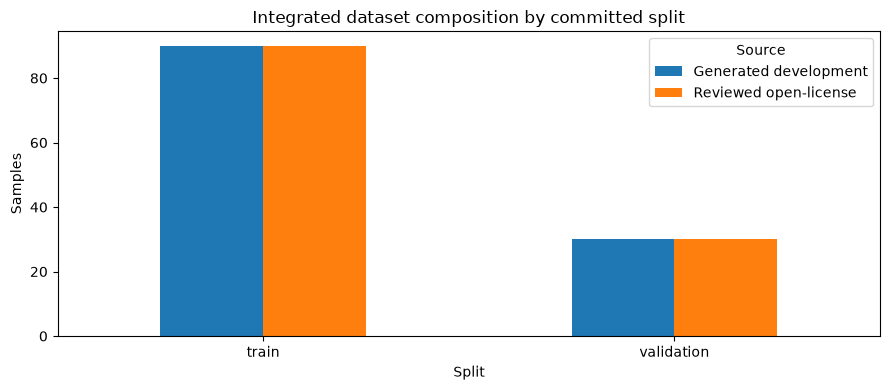

In [3]:
source_display_names = {
    "generated_development": "Generated development",
    "wikimedia_commons_open_license": "Reviewed open-license",
}

composition = (
    pd.concat([
        train_df.assign(split="train"),
        validation_df.assign(split="validation"),
    ])
    .groupby(["split", "source"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=source_display_names)
)

ax = composition.plot(kind="bar", figsize=(9, 4))
ax.set_title("Integrated dataset composition by committed split")
ax.set_xlabel("Split")
ax.set_ylabel("Samples")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Source")
plt.tight_layout()
plt.show()


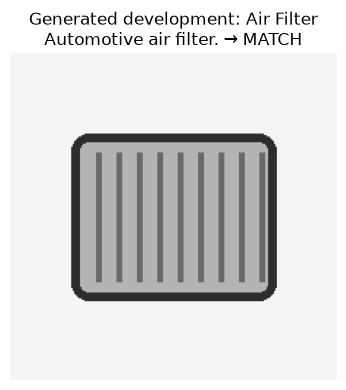

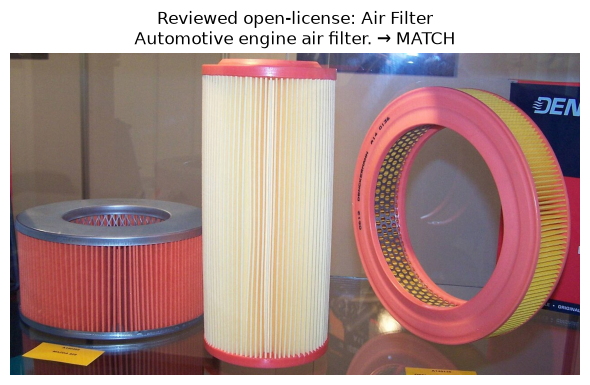

In [4]:
examples = pd.concat([
    train_df[train_df["source"] == "generated_development"].head(1),
    train_df[train_df["source"] == "wikimedia_commons_open_license"].head(1),
], ignore_index=True)

for row in examples.itertuples(index=False):
    image = Image.open(ROOT / row.image_path).convert("RGB")
    plt.figure(figsize=(6, 4))
    plt.imshow(image)
    plt.axis("off")
    source_name = source_display_names.get(row.source, row.source)
    category_name = row.part_category.replace("_", " ").title()
    plt.title(f"{source_name}: {category_name}\n{row.description} → {row.label}")
    plt.tight_layout()
    plt.show()


## 6. Data cleaning and grouped split

The cleaning and formatting pipeline validates identifiers, category-family mappings, safe relative paths, readable images, hashes, duplicate content, approval state, and label balance. The integrated training and validation inputs contain ten automotive categories and equal numbers of all three relationship labels.

The critical statistical safeguard is **group isolation**. All three rows derived from the same physical part stay in one split. This prevents the model from seeing one pairing from a part during training and another pairing from the same part during validation.


In [5]:
train_groups = set(train_df["part_group_id"])
validation_groups = set(validation_df["part_group_id"])

group_audit = pd.DataFrame([
    {
        "train groups": len(train_groups),
        "validation groups": len(validation_groups),
        "train-validation overlap": len(train_groups & validation_groups),
        "train label counts": train_df["label"].value_counts().sort_index().to_dict(),
        "validation label counts": validation_df["label"].value_counts().sort_index().to_dict(),
    }
])

display(group_audit)
assert not (train_groups & validation_groups)


,train groups,validation groups,train-validation overlap,train label counts,validation label counts
0,60,20,0,"{'MATCH': 60, 'MISMATCH': 60, 'PARTIAL_MATCH':...","{'MATCH': 20, 'MISMATCH': 20, 'PARTIAL_MATCH':..."


## 7. Models and experimental design

Six model families were compared under the same integrated train/validation boundary:

- majority baseline;
- TF-IDF [5] with Logistic Regression [6];
- resized image pixels with Logistic Regression [6];
- Keras text neural network;
- Keras image neural network;
- Keras multimodal neural network.

The final multimodal architecture has separate text and image branches. The text branch uses token embeddings and global average pooling. The image branch uses rescaling, flattening, and dense layers. Their representations are concatenated and passed through a fusion classifier. The design is intentionally compact so that the contribution of multimodal information can be compared without a large pretrained backbone.


In [6]:
model_table = comparison_df[[
    "validation_rank",
    "model",
    "input_modality",
    "integrated_validation_accuracy",
    "integrated_validation_macro_f1",
    "development_validation_accuracy",
    "development_validation_macro_f1",
]].copy()

model_table.columns = [
    "rank",
    "model",
    "modality",
    "integrated accuracy",
    "integrated macro F1",
    "development accuracy",
    "development macro F1",
]

display(model_table.round(4))


,rank,model,modality,integrated accuracy,integrated macro F1,development accuracy,development macro F1
0,1,Keras Multimodal Neural Network,image_and_text,0.5333,0.5208,0.7667,0.7696
1,2,TF-IDF + Logistic Regression,text,0.4167,0.3300,0.5000,0.3889
2,3,Keras Text Neural Network,text,0.4167,0.3300,0.5000,0.3889
3,4,Majority baseline,none,0.3333,0.1667,0.3333,0.1667
4,5,Image pixels + Logistic Regression,image,0.3333,0.1667,0.3333,0.1667
5,6,Keras Image Neural Network,image,0.3333,0.1667,0.3333,0.1667


## 8. Development and integrated validation results

The multimodal model ranked first on the integrated validation split. Its performance declined relative to the easier generated development split, which is an important result rather than a failure: the open-license photographs introduce realistic variation in background, viewpoint, scale, and object presentation.

The gap between development and integrated validation also warns against reporting only generated-data results. The integrated comparison is the more credible estimate for the current project stage.


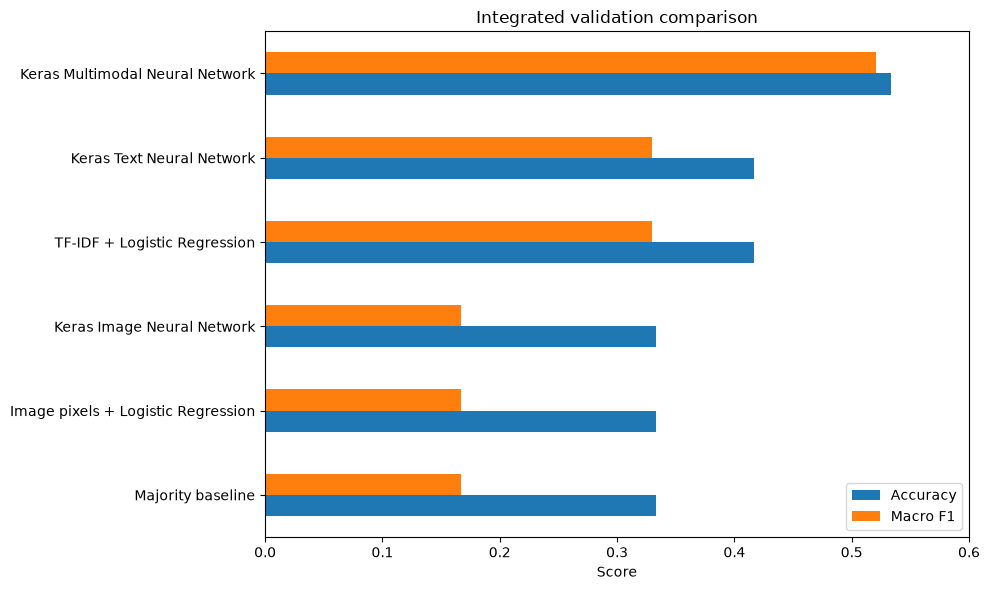

In [7]:
plot_df = comparison_df.sort_values("integrated_validation_macro_f1")
ax = plot_df.plot(
    x="model",
    y=["integrated_validation_accuracy", "integrated_validation_macro_f1"],
    kind="barh",
    figsize=(10, 6),
)
ax.set_title("Integrated validation comparison")
ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_xlim(0, 0.60)
ax.legend(["Accuracy", "Macro F1"])
plt.tight_layout()
plt.show()


In [8]:
best = comparison_df.sort_values("validation_rank").iloc[0]
performance_summary = pd.DataFrame([
    {
        "selected model": best["model"],
        "integrated validation accuracy": best["integrated_validation_accuracy"],
        "integrated validation macro F1": best["integrated_validation_macro_f1"],
        "development validation accuracy": best["development_validation_accuracy"],
        "development validation macro F1": best["development_validation_macro_f1"],
        "macro F1 change": best["macro_f1_change"],
    }
])
display(performance_summary.round(4))


,selected model,integrated validation accuracy,integrated validation macro F1,development validation accuracy,development validation macro F1,macro F1 change
0,Keras Multimodal Neural Network,0.5333,0.5208,0.7667,0.7696,-0.2488


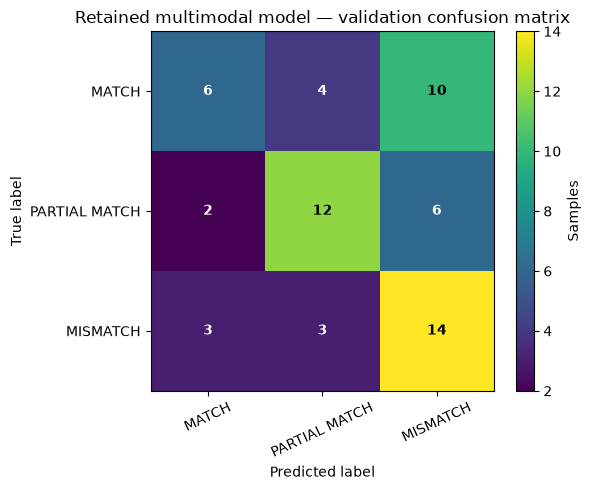

In [9]:
confusion = pd.read_csv(CONFUSION_MATRIX_CSV, index_col=0)
confusion_values = confusion.to_numpy()

fig = plt.figure(figsize=(6, 5))
image = plt.imshow(confusion_values, aspect="auto")
plt.xticks(
    range(len(confusion.columns)),
    [c.replace("predicted_", "").replace("_", " ") for c in confusion.columns],
    rotation=25,
)
plt.yticks(
    range(len(confusion.index)),
    [i.replace("actual_", "").replace("_", " ") for i in confusion.index],
)
plt.title("Retained multimodal model — validation confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")

contrast_threshold = (confusion_values.max() + confusion_values.min()) / 2
for row_index in range(confusion.shape[0]):
    for column_index in range(confusion.shape[1]):
        value = int(confusion.iloc[row_index, column_index])
        text_color = "black" if value > contrast_threshold else "white"
        plt.text(
            column_index,
            row_index,
            value,
            ha="center",
            va="center",
            color=text_color,
            fontweight="bold",
        )

plt.colorbar(image, label="Samples")
plt.tight_layout()
plt.show()


In [10]:
per_class = pd.DataFrame(metrics["per_class"]).T
per_class.index.name = "label"
display(per_class[["precision", "recall", "f1", "support"]].round(4))


,precision,recall,f1,support
label,,,,
MATCH,0.5455,0.3,0.3871,20.0
PARTIAL_MATCH,0.6316,0.6,0.6154,20.0
MISMATCH,0.4667,0.7,0.5600,20.0


## 9. Validation error analysis

The retained Step 010.3 multimodal model made **28 errors among 60 validation samples**. The middle relationship class remains difficult because `PARTIAL_MATCH` requires the model to identify both a category difference and a shared automotive family. The largest single error type is `MATCH → MISMATCH`, showing that some exact relationships are missed when realistic photographs differ from the cleaner generated examples.

The table and chart below are derived directly from the retained model's committed validation predictions. The separate Step 010.4 controlled rerun produced 35 errors for its newly retrained reference candidate; those rerun errors are not presented as errors of the retained incumbent. No new split is introduced, and the locked test data remains untouched.


,error pair,count
0,MATCH → MISMATCH,10
1,PARTIAL MATCH → MISMATCH,6
2,MATCH → PARTIAL MATCH,4
3,MISMATCH → MATCH,3
4,MISMATCH → PARTIAL MATCH,3
5,PARTIAL MATCH → MATCH,2


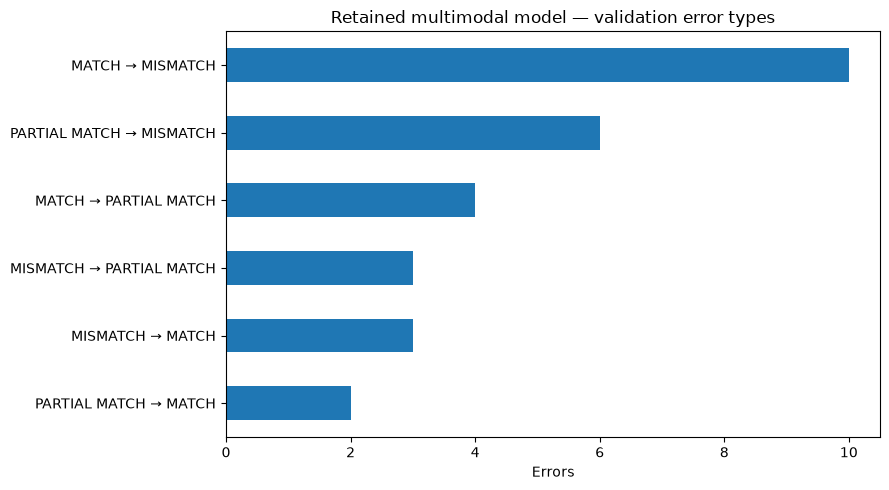

In [11]:
predictions = pd.read_csv(PREDICTIONS_CSV)
retained_errors = predictions.loc[~predictions["is_correct"]].copy()
retained_errors["error pair"] = (
    retained_errors["true_label"].str.replace("_", " ")
    + " → "
    + retained_errors["predicted_label"].str.replace("_", " ")
)
error_pairs = (
    retained_errors["error pair"]
    .value_counts()
    .rename_axis("error pair")
    .reset_index(name="count")
)
display(error_pairs)

ax = error_pairs.sort_values("count").plot(
    x="error pair",
    y="count",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("Retained multimodal model — validation error types")
ax.set_xlabel("Errors")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


In [12]:
source_accuracy = (
    predictions.groupby("source")["is_correct"]
    .mean()
    .rename("validation accuracy")
    .reset_index()
)
source_accuracy["source"] = source_accuracy["source"].map(source_display_names)

category_accuracy = (
    predictions.groupby("part_category")["is_correct"]
    .mean()
    .sort_values()
    .rename("validation accuracy")
    .reset_index()
)
category_accuracy["part_category"] = (
    category_accuracy["part_category"].str.replace("_", " ").str.title()
)

display(source_accuracy.round(4))
display(category_accuracy.round(4))


,source,validation accuracy
0,Generated development,0.6000
1,Reviewed open-license,0.4667


,part_category,validation accuracy
0,Coil Spring,0.1667
1,Taillight,0.3333
2,Headlight,0.5000
3,Air Filter,0.5000
4,Brake Disc,0.5000
5,Brake Pad,0.6667
6,Oil Filter,0.6667
7,Alternator,0.6667
8,Shock Absorber,0.6667
9,Starter,0.6667


## 10. Controlled model improvement and selection

Three predefined multimodal candidates were trained across fixed seeds after the error analysis. The relation-aware candidate improved the repeated-seed mean and aggregate validation result relative to the newly retrained reference candidate. However, the project used an **incumbent guard** against the stronger Step 010.3 multimodal result. The candidate did not satisfy all predefined conditions, so the decision was `REFERENCE_RETAINED`.

This conservative decision avoids promoting a model merely because it wins within a weaker rerun. It also documents a negative experimental result rather than hiding it.


In [13]:
controlled = pd.read_csv(CONTROLLED_COMPARISON_CSV)
display(controlled[[
    "validation_rank",
    "candidate",
    "aggregate_validation_accuracy",
    "aggregate_validation_macro_f1",
    "mean_seed_macro_f1",
    "std_seed_macro_f1",
    "worst_class_f1",
    "parameter_count",
]].round(4))

selection_summary = pd.DataFrame([
    {
        "decision": selection["decision"],
        "selected family": selection["selected_candidate_slug"],
        "Step 010.3 incumbent macro F1": selection["incumbent_validation_macro_f1"],
        "final-test authorization": selection["final_test_evaluation_authorized"],
    }
])
display(selection_summary.round(4))


,validation_rank,candidate,aggregate_validation_accuracy,aggregate_validation_macro_f1,mean_seed_macro_f1,std_seed_macro_f1,worst_class_f1,parameter_count
0,1,Relation-Aware Multimodal,0.5000,0.4879,0.4646,0.0396,0.4375,122595
1,2,Reference Multimodal,0.4167,0.3333,0.3583,0.0500,0.0000,117987
2,3,Regularized Relation-Aware Multimodal,0.4167,0.3300,0.3485,0.0258,0.0000,120827


,decision,selected family,Step 010.3 incumbent macro F1,final-test authorization
0,REFERENCE_RETAINED,reference_multimodal,0.5208,False


## 11. Final model and locked-test protocol freeze

Step 010.5 freezes the **model recipe**, preprocessing contract, label order, training settings, checkpoint-selection rule, environment fingerprint, and future one-shot evaluation metrics. Serialized trained weights are not falsely claimed as committed; the future protocol specifies exact reconstruction from the frozen recipe.

Protocol freeze is not test authorization. The current authorization flag remains `false`, and this notebook does not open, parse, predict on, or evaluate the final test split.


In [14]:
architecture = model_spec["architecture_contract"]
training_contract = model_spec["training_contract"]

freeze_table = pd.DataFrame([
    {"item": "Final model", "frozen value": model_spec["final_model"]},
    {"item": "Model family", "frozen value": model_spec["final_model_family"]},
    {"item": "Validation macro F1", "frozen value": model_spec["validation_evidence"]["macro_f1"]},
    {"item": "Trainable parameters", "frozen value": architecture["trainable_parameter_count"]},
    {"item": "Random state", "frozen value": training_contract["random_state"]},
    {"item": "Batch size", "frozen value": training_contract["batch_size"]},
    {"item": "Checkpoint rule", "frozen value": training_contract["checkpoint_selection_rule"]},
    {"item": "Protocol state", "frozen value": protocol["protocol_state"]},
    {"item": "Serialized weights committed", "frozen value": model_spec["serialized_weights_committed"]},
    {"item": "Final-test authorized", "frozen value": authorization["authorized"]},
])

display(freeze_table)


,item,frozen value
0,Final model,Keras Multimodal Neural Network
1,Model family,reference_multimodal
2,Validation macro F1,0.520827
3,Trainable parameters,117987
4,Random state,42
5,Batch size,32
6,Checkpoint rule,minimum_validation_loss
7,Protocol state,FROZEN_NOT_AUTHORIZED
8,Serialized weights committed,False
9,Final-test authorized,False


## 12. Testing and reproducibility

The repository separates dataset creation, validation, model workflows, reporting, and verification into reusable modules exposed through a central CLI. Tests cover grouped splitting, model outputs, licensing and attribution, real-data intake, transactional operations, repository hygiene, validation-only model selection, final model freeze, and locked-test safeguards.

At the Step 010.5 checkpoint, the full project environment reported **275 passing tests** with **154 known dependency warnings**. Step 010.6 integrated this notebook at commit `2f41d84`. The dependency environment is pinned in `requirements-lock.txt`. Random seeds and deterministic TensorFlow operations are enabled where supported, while the report acknowledges that small numerical differences may occur across hardware and TensorFlow builds.


In [15]:
reproducibility = pd.DataFrame([
    {"control": "Step 010.5 base checkpoint", "value": "d517668"},
    {"control": "Notebook integration commit", "value": "2f41d84"},
    {"control": "Verified tests at Step 010.5", "value": 275},
    {"control": "Known dependency warnings", "value": 154},
    {"control": "Dependency lock", "value": "requirements-lock.txt"},
    {"control": "Group overlap", "value": len(train_groups & validation_groups)},
    {"control": "Test split used", "value": freeze_status["test_split_used"]},
    {"control": "Final-test authorized", "value": authorization["authorized"]},
])
display(reproducibility)


,control,value
0,Step 010.5 base checkpoint,d517668
1,Notebook integration commit,2f41d84
2,Verified tests at Step 010.5,275
3,Known dependency warnings,154
4,Dependency lock,requirements-lock.txt
5,Group overlap,0
6,Test split used,False
7,Final-test authorized,False


## 13. Limitations and threats to validity

- The integrated dataset is still small: 180 training and 60 validation rows derived from 80 physical part groups.
- Three rows are generated per image, so group-level splitting is essential and the effective independent sample size is the number of groups rather than rows.
- The generated source is cleaner than the open-license photographs and can overestimate performance.
- The image branch is a compact dense model over resized pixels rather than a pretrained convolutional or vision-transformer encoder.
- Short templated descriptions limit linguistic diversity.
- Validation results have uncertainty because the validation split contains only 20 physical groups.
- The controlled improvement study did not produce a candidate that passed the incumbent guard.
- No final test metric is reported because the test split remains locked and unauthorized at this stage.

These limitations make the project an honest baseline and a reproducible research foundation, not a production-ready automotive catalogue system.


## 14. Conclusion and future work

The results support the central hypothesis: the multimodal model is the strongest of the evaluated integrated validation models because the task depends on the relationship between image and text. Its macro F1 of `0.5208` exceeds both text-only and image-only alternatives, although the integrated result is substantially lower than the generated development result.

The project contributes a reproducible end-to-end workflow: controlled label construction, open-license data provenance, grouped splitting, classical and neural baselines, validation error analysis, guarded model selection, extensive testing, and a frozen future evaluation protocol.

Future work should expand the number of independently photographed part groups, increase description diversity, evaluate pretrained visual encoders, and investigate better relation-aware fusion. Any final test evaluation must remain a separate, explicitly authorized, one-shot procedure after the notebook and submission package are fully reviewed.


## 15. References

1. Faghri, F., Fleet, D. J., Kiros, J. R., & Fidler, S. (2018). **VSE++: Improving Visual-Semantic Embeddings with Hard Negatives.** British Machine Vision Conference. [Official BMVC paper](https://bmvc2018.org/contents/papers/0344.pdf)
2. Li, L. H., Yatskar, M., Yin, D., Hsieh, C.-J., & Chang, K.-W. (2019). **VisualBERT: A Simple and Performant Baseline for Vision and Language.** [arXiv:1908.03557](https://arxiv.org/abs/1908.03557)
3. Radford, A., et al. (2021). **Learning Transferable Visual Models From Natural Language Supervision.** Proceedings of the 38th International Conference on Machine Learning. [PMLR 139](https://proceedings.mlr.press/v139/radford21a.html)
4. TensorFlow. **The Functional API.** [Official TensorFlow guide](https://www.tensorflow.org/guide/keras/functional_api)
5. scikit-learn. **TfidfVectorizer documentation.** [Official API reference](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)
6. scikit-learn. **LogisticRegression documentation.** [Official API reference](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

### Reproduction commands

```powershell
python -m src.project_cli build-final-exam-notebook
python -m src.project_cli verify-final-exam-notebook
python -m pytest -q
python -m src.project_cli verify-project
```
